In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
# To access the dataset to be used.
df = pd.read_csv(r"C:\Users\omale\Documents\python_class\ai_student_impact_dataset.csv")
df.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


In [3]:
# To drop the columns that we don't need. 
df.drop(["Student_ID", "Institutional_Policy", "Prompt_Engineering_Skill", "Paid_Subscription"], axis = 1, inplace = True)
# Algorithms to use Random forest Classifer, XGBoost, Catboost 

In [4]:
df.columns.to_list()

['Major_Category',
 'Year_of_Study',
 'Pre_Semester_GPA',
 'Weekly_GenAI_Hours',
 'Primary_Use_Case',
 'Tool_Diversity',
 'Traditional_Study_Hours',
 'Perceived_AI_Dependency',
 'Anxiety_Level_During_Exams',
 'Post_Semester_GPA',
 'Skill_Retention_Score',
 'Burnout_Risk_Level']

In [4]:
df.head()

,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,Humanities,Senior,2.418,23.31,Copywriting/Drafting,1,8.13,5,6,2.393,86.44,High
1,Medical,Junior,3.821,1.12,Ideation,5,16.65,3,9,3.696,69.39,Low
2,Business,Freshman,3.398,21.26,Summarizing_Reading,2,10.35,5,9,3.499,73.93,Medium
3,Business,Senior,3.789,1.82,Copywriting/Drafting,4,15.23,2,2,4.000,63.58,Medium
4,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,4,12.55,4,4,3.798,100.00,Medium


In [5]:
df.columns.to_list()

['Major_Category',
 'Year_of_Study',
 'Pre_Semester_GPA',
 'Weekly_GenAI_Hours',
 'Primary_Use_Case',
 'Tool_Diversity',
 'Traditional_Study_Hours',
 'Perceived_AI_Dependency',
 'Anxiety_Level_During_Exams',
 'Post_Semester_GPA',
 'Skill_Retention_Score',
 'Burnout_Risk_Level']

In [6]:
# To check for Missing values.
df.isnull().sum()

Major_Category                0
Year_of_Study                 0
Pre_Semester_GPA              0
Weekly_GenAI_Hours            0
Primary_Use_Case              0
Tool_Diversity                0
Traditional_Study_Hours       0
Perceived_AI_Dependency       0
Anxiety_Level_During_Exams    0
Post_Semester_GPA             0
Skill_Retention_Score         0
Burnout_Risk_Level            0
dtype: int64

In [7]:
# To check for Dtypes 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Major_Category              50000 non-null  object 
 1   Year_of_Study               50000 non-null  object 
 2   Pre_Semester_GPA            50000 non-null  float64
 3   Weekly_GenAI_Hours          50000 non-null  float64
 4   Primary_Use_Case            50000 non-null  object 
 5   Tool_Diversity              50000 non-null  int64  
 6   Traditional_Study_Hours     50000 non-null  float64
 7   Perceived_AI_Dependency     50000 non-null  int64  
 8   Anxiety_Level_During_Exams  50000 non-null  int64  
 9   Post_Semester_GPA           50000 non-null  float64
 10  Skill_Retention_Score       50000 non-null  float64
 11  Burnout_Risk_Level          50000 non-null  object 
dtypes: float64(5), int64(3), object(4)
memory usage: 4.6+ MB


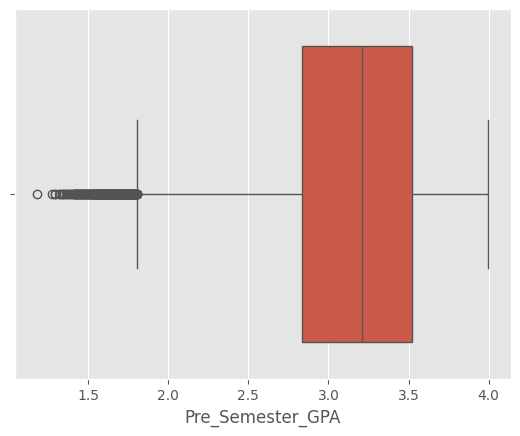

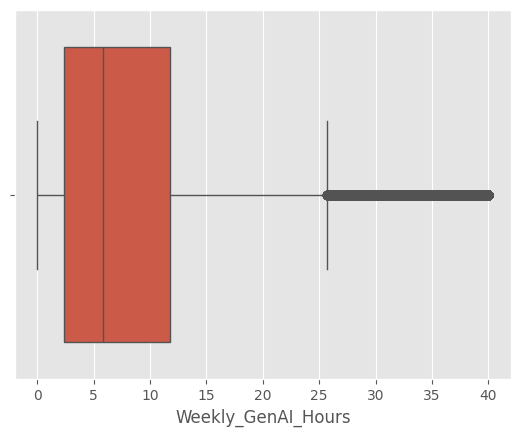

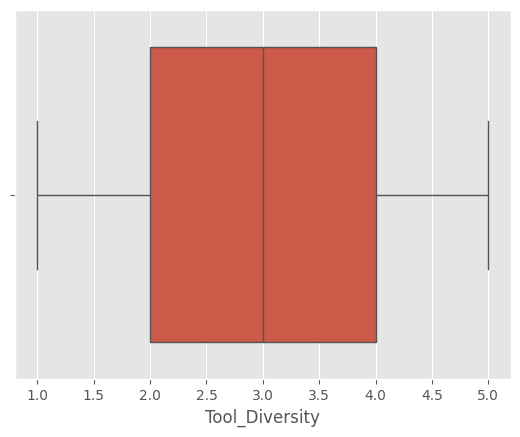

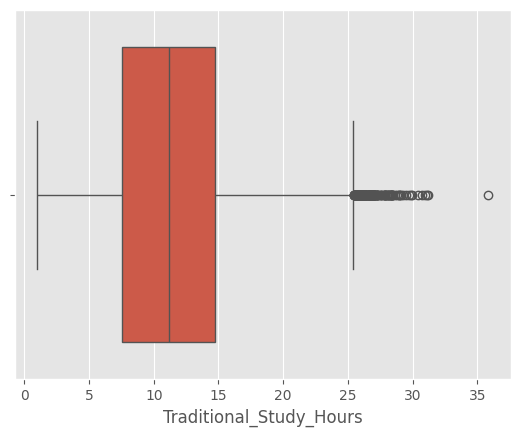

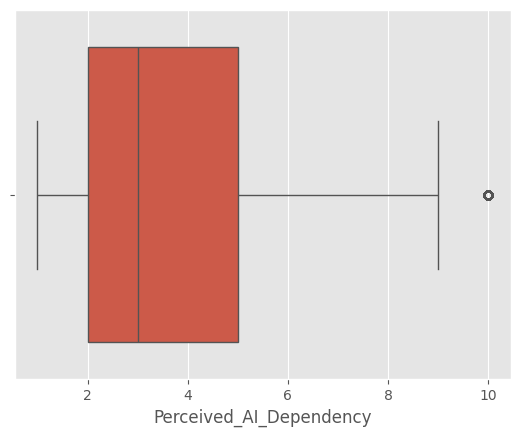

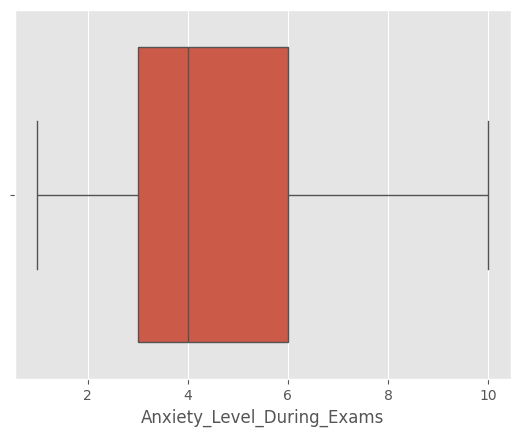

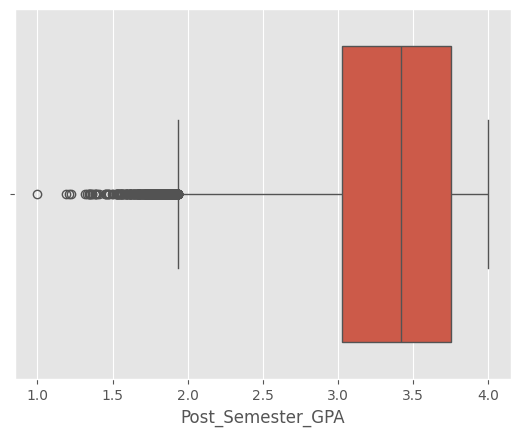

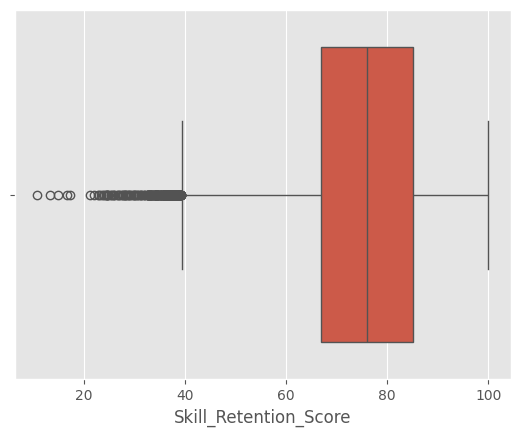

In [8]:
# To select all columns that are numerical and check for outliers.
num_col = df.select_dtypes(include = ["int", "float"]).columns 

for i in num_col:
    plt.style.use("ggplot")
    sns.boxplot(x = df[i])
    plt.show()

In [5]:
# To create a function to calculate the lower bound and higher bound 
# pip install nbformat, matplotlib 
# iqr means inter quaterly range
def calculate_bound(col):
    q1, q3 = np.percentile(col, [25, 75])
    iqr = q3 - q1
    lb = q1 - 1.5 * iqr 
    ub = q3 + 1.5 * iqr
    return lb, ub 

In [10]:
# Using Winsorization Method to handle Outliers 
for i in num_col:
    lb, ub = calculate_bound(df[i])
    df[i] = np.where(df[i] < lb, lb, df[i])
    df[i] = np.where(df[i] > ub, ub, df[i])

In [11]:
df.head()

,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,Humanities,Senior,2.418,23.31,Copywriting/Drafting,1.0,8.13,5.0,6.0,2.393,86.44,High
1,Medical,Junior,3.821,1.12,Ideation,5.0,16.65,3.0,9.0,3.696,69.39,Low
2,Business,Freshman,3.398,21.26,Summarizing_Reading,2.0,10.35,5.0,9.0,3.499,73.93,Medium
3,Business,Senior,3.789,1.82,Copywriting/Drafting,4.0,15.23,2.0,2.0,4.000,63.58,Medium
4,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,4.0,12.55,4.0,4.0,3.798,100.00,Medium


In [12]:
# To select all the columns that are categorical.
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
cat_col = df.select_dtypes(include = "object").columns 

# To categorize the columns 
label_col ='Burnout_Risk_Level'
ordinal_col = ['Major_Category','Year_of_Study' 'Primary_Use_Case']

le = LabelEncoder()
oe = OrdinalEncoder()

df[label_col] = le.fit_transform(df[[label_col]])

for col in cat_col:
    df[col]  = oe.fit_transform(df[[col]])

df.head()


c:\Users\Neptune\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,2.0,3.0,2.418,23.31,0.0,1.0,8.13,5.0,6.0,2.393,86.44,0.0
1,3.0,2.0,3.821,1.12,3.0,5.0,16.65,3.0,9.0,3.696,69.39,1.0
2,1.0,0.0,3.398,21.26,4.0,2.0,10.35,5.0,9.0,3.499,73.93,2.0
3,1.0,3.0,3.789,1.82,0.0,4.0,15.23,2.0,2.0,4.000,63.58,2.0
4,4.0,4.0,3.635,9.29,1.0,4.0,12.55,4.0,4.0,3.798,100.00,2.0


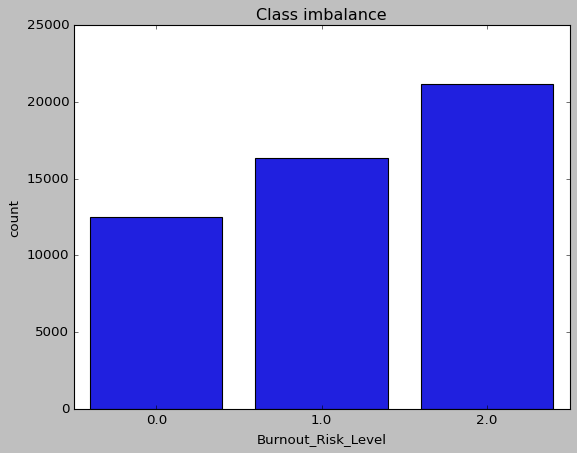

In [13]:
# To identify Class imbalance.
plt.style.use("classic")
plt.figure(figsize=(8, 6))
sns.countplot(x = df['Burnout_Risk_Level'] )
plt.title("Class imbalance")
plt.show()

In [14]:
# To get the value count of each segement in a column.
df['Burnout_Risk_Level'].value_counts()

Burnout_Risk_Level
2.0    21144
1.0    16369
0.0    12487
Name: count, dtype: int64

In [15]:
# To select each segement Individually.
from sklearn.utils import resample
df1 = df[df['Burnout_Risk_Level'] == 0]
df2 = df[df['Burnout_Risk_Level'] == 1]
df3 = df[df['Burnout_Risk_Level'] == 2]

df_sam1 = resample(df1, replace=True, n_samples= 21144)
df_sam2 = resample(df2, replace=True, n_samples= 21144)

# To concate all segements together. 
df_main = pd.concat([df_sam1, df_sam2, df3])

df = df_main.sample(frac = 1, ignore_index = True)

In [16]:
# pip install xgboost, catboost
# Data Splitting 
from sklearn.model_selection import train_test_split
x = df.drop('Burnout_Risk_Level', axis = 1)
y = df['Burnout_Risk_Level']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state= 42)

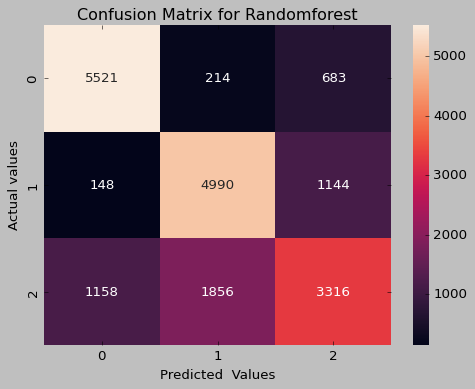


              precision    recall  f1-score   support

         0.0       0.81      0.86      0.83      6418
         1.0       0.71      0.79      0.75      6282
         2.0       0.64      0.52      0.58      6330

    accuracy                           0.73     19030
   macro avg       0.72      0.73      0.72     19030
weighted avg       0.72      0.73      0.72     19030

Accuracy Score: 0.73


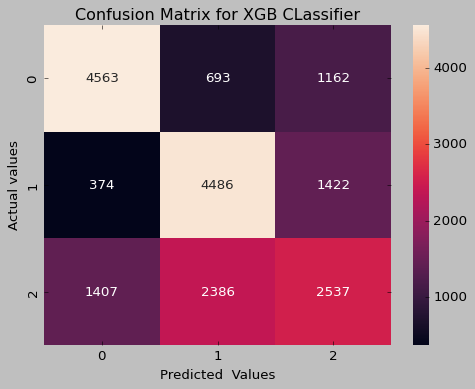


              precision    recall  f1-score   support

         0.0       0.72      0.71      0.72      6418
         1.0       0.59      0.71      0.65      6282
         2.0       0.50      0.40      0.44      6330

    accuracy                           0.61     19030
   macro avg       0.60      0.61      0.60     19030
weighted avg       0.60      0.61      0.60     19030

Accuracy Score: 0.61


In [17]:
# Import the various algorithmns.
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
Models = {"Randomforest": RandomForestClassifier(n_estimators= 42), "XGB CLassifier":XGBClassifier()}
for Names, Model in Models.items():
    Model.fit(x_train, y_train)
    
    y_pred = Model.predict(x_test)
    
    classification = classification_report(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot = True, fmt = "0.5g", cbar="rocket")
    plt.xlabel("Predicted  Values")
    plt.ylabel("Actual values")
    plt.title(f"Confusion Matrix for {Names}")
    plt.show()
    
    print("\n" + "=" * 35)
    print(classification)
    print('Accuracy Score:', round(accuracy,2))

In [ ]:
plt.style.available

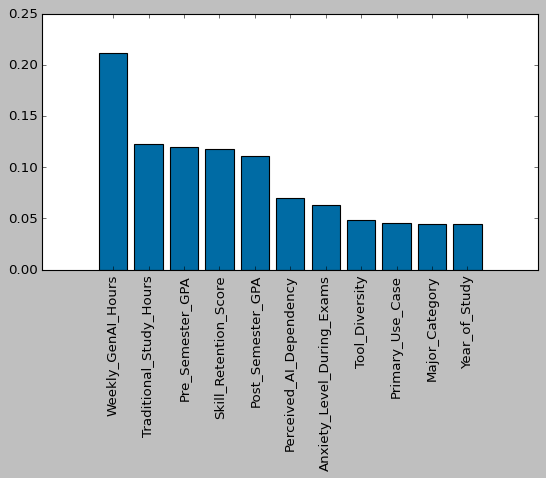

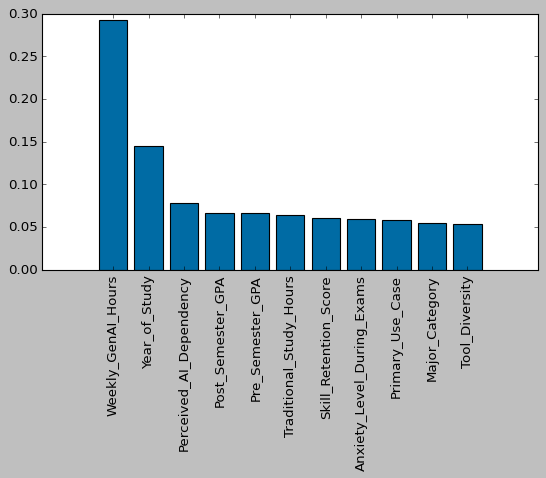

In [105]:
#To display the features with the Highest correlation with the Target variables.
for Names, Model in Models.items():
    features = Model.feature_importances_
    ratio = np.argsort(features)[::-1]
    
    plt.style.use("tableau-colorblind10")
    plt.figure(figsize=(8, 4))
    plt.bar(range(x.shape[1]), features[ratio], align = "center")
    plt.xticks(range(x.shape[1]), x.columns[ratio], rotation = "vertical" )
    plt.show()

In [104]:
# To transfer a model to a file
import joblib as jb 
jb.dump(Models["Randomforest"], "AI_impact.pki", compress = 6)
print("Success, check your Python class folder..")

Success, check your Python class folder..


In [22]:
# pip install catboost
df.columns.to_list()

['Major_Category',
 'Year_of_Study',
 'Pre_Semester_GPA',
 'Weekly_GenAI_Hours',
 'Primary_Use_Case',
 'Tool_Diversity',
 'Traditional_Study_Hours',
 'Perceived_AI_Dependency',
 'Anxiety_Level_During_Exams',
 'Post_Semester_GPA',
 'Skill_Retention_Score',
 'Burnout_Risk_Level']

              precision    recall  f1-score   support

         0.0       0.79      0.85      0.82      6418
         1.0       0.68      0.78      0.72      6282
         2.0       0.62      0.48      0.54      6330

    accuracy                           0.70     19030
   macro avg       0.70      0.70      0.70     19030
weighted avg       0.70      0.70      0.70     19030

0.7048870204939569


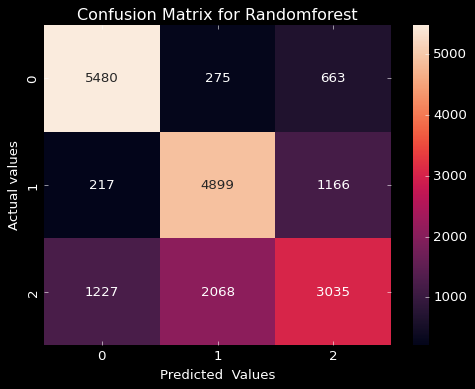

              precision    recall  f1-score   support

         0.0       0.69      0.68      0.69      6418
         1.0       0.55      0.70      0.61      6282
         2.0       0.47      0.35      0.40      6330

    accuracy                           0.58     19030
   macro avg       0.57      0.58      0.57     19030
weighted avg       0.57      0.58      0.57     19030

0.5762480294272202


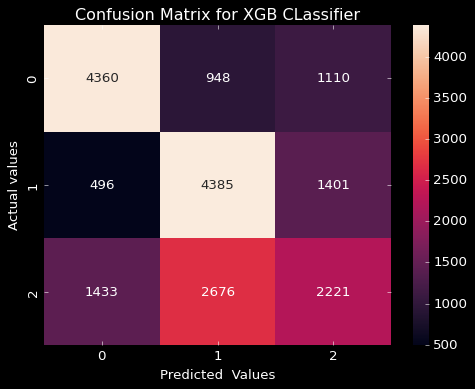

In [25]:
x_samples = x_train[["Weekly_GenAI_Hours",'Traditional_Study_Hours', 'Pre_Semester_GPA','Skill_Retention_Score', 'Post_Semester_GPA']]
tests = x_test[["Weekly_GenAI_Hours",'Traditional_Study_Hours', 'Pre_Semester_GPA','Skill_Retention_Score', 'Post_Semester_GPA']]
for Names, Model in Models.items():
    Model.fit(x_samples, y_train)
    
    Prediction = Model.predict(tests)
    
    print(classification_report(y_test, Prediction))
    
    print(accuracy_score(y_test, Prediction))
        
    cm = confusion_matrix(y_test, Prediction)
    
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot = True, fmt = "0.5g", cbar="rocket")
    plt.xlabel("Predicted  Values")
    plt.ylabel("Actual values")
    plt.title(f"Confusion Matrix for {Names}")
    plt.show()
    


In [4]:
df.columns.to_list()

['Major_Category',
 'Year_of_Study',
 'Pre_Semester_GPA',
 'Weekly_GenAI_Hours',
 'Primary_Use_Case',
 'Tool_Diversity',
 'Traditional_Study_Hours',
 'Perceived_AI_Dependency',
 'Anxiety_Level_During_Exams',
 'Post_Semester_GPA',
 'Skill_Retention_Score',
 'Burnout_Risk_Level']

In [ ]:
# From the Dataset above, Generate the following, using the columns() : 
# 1. list of unique values in the categorical Columns.
# 2. On the Numerical columns list the Min and max values. 
# 3. Generate a Python script that use Streamlit to enter the list of columns specified above 
# 4. Inside the Python script, create a function that will load the model to make a Prediction.

In [1]:
pip install zipfile

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement zipfile (from versions: none)

[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for zipfile


In [ ]:
import zipfile

input_file = "AI_impact.pki"
zip_filename = "AI_model_archive.zip"

with zipfile.ZipFile(zip_filename, "w", compression= zipfile.ZIP_DEFLATED) as zipf:
    zipf.write(input_file, arcname="AI_impact.pki")

In [6]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement streamlit (from versions: none)
ERROR: No matching distribution found for streamlit
